In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/heart_diseases.csv')
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [64]:
df['target'].value_counts()

target
1    629
0    561
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


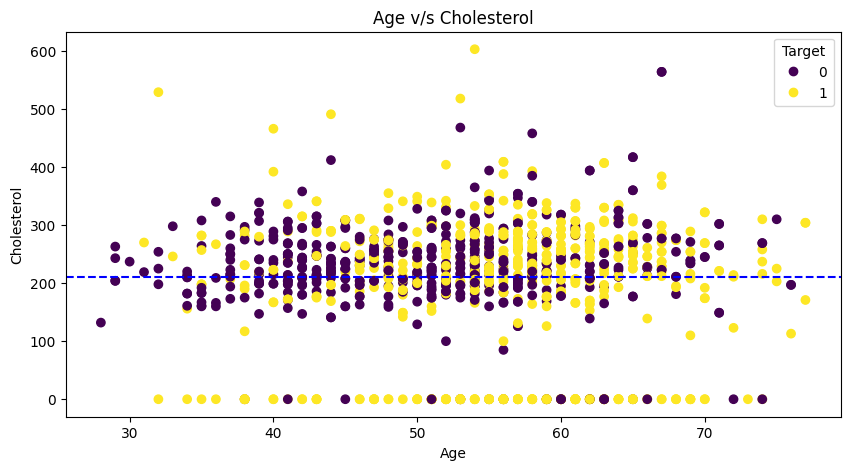

In [28]:
fig, ax = plt.subplots(figsize=(10,5))

scatter = ax.scatter(x=df.age, y=df.cholesterol, c=df.target)
ax.legend(*scatter.legend_elements(), title='Target')
ax.set(title='Age v/s Cholesterol',
       xlabel='Age',
       ylabel='Cholesterol')
ax.axhline(y= np.mean(df.cholesterol.mean()),color='b', linestyle='--');

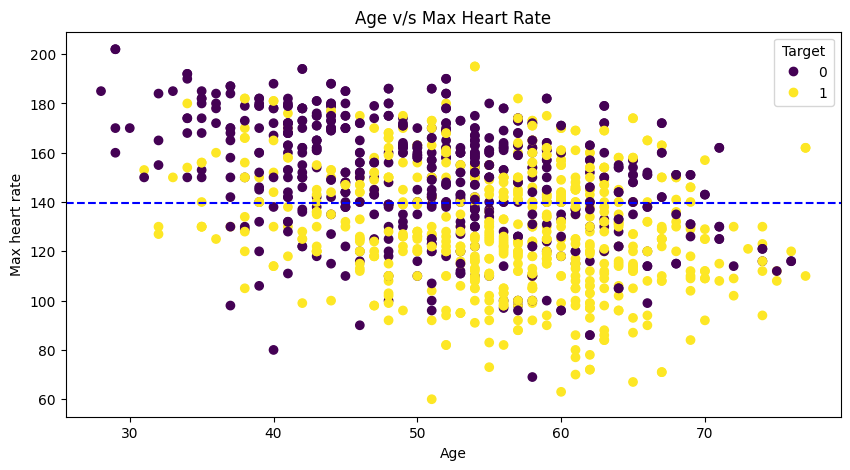

In [18]:
fig, ax = plt.subplots(figsize=(10,5))

scatter = ax.scatter(x=df.age, y=df['max heart rate'], c=df.target)
ax.legend(*scatter.legend_elements(), title='Target')
ax.set(title='Age v/s Max Heart Rate',
       xlabel='Age',
       ylabel='Max heart rate')
ax.axhline(y= np.mean(df['max heart rate'].mean()),color='b', linestyle='--');

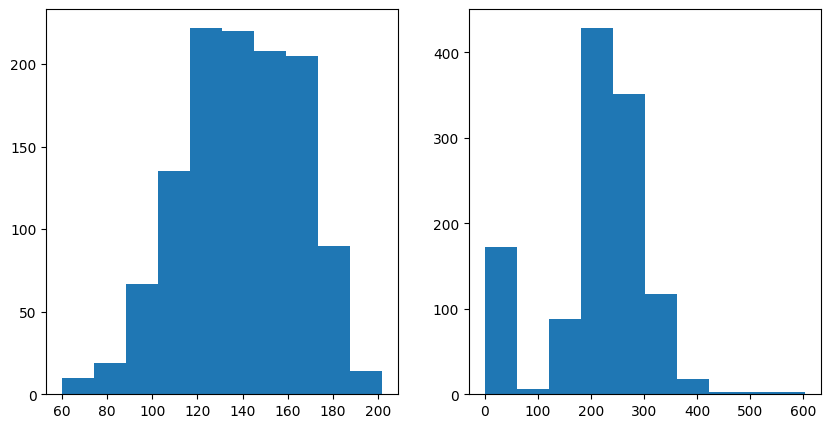

In [34]:
fig, ((ax1,ax2)) = plt.subplots(figsize=(10,5),
                              nrows=1,
                              ncols=2)

ax1.hist(df['max heart rate']);
ax2.hist(df['cholesterol']);




In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = df.drop('target', axis=1)
y = df.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

clf.score(X_test, y_test)


0.9495798319327731

In [40]:
from sklearn.model_selection import cross_val_score

cvs = np.mean(cross_val_score(clf,X,y))
cvs

0.9235294117647059

In [43]:
y_preds = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)


In [45]:
y_proba[:10]

array([[0.1 , 0.9 ],
       [0.5 , 0.5 ],
       [0.92, 0.08],
       [0.08, 0.92],
       [0.11, 0.89],
       [0.03, 0.97],
       [0.96, 0.04],
       [0.6 , 0.4 ],
       [0.82, 0.18],
       [0.97, 0.03]])

In [46]:
y_proba_positive = y_proba[:,1]
y_proba_positive[:10]

array([0.9 , 0.5 , 0.08, 0.92, 0.89, 0.97, 0.04, 0.4 , 0.18, 0.03])

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_test, y_proba_positive)


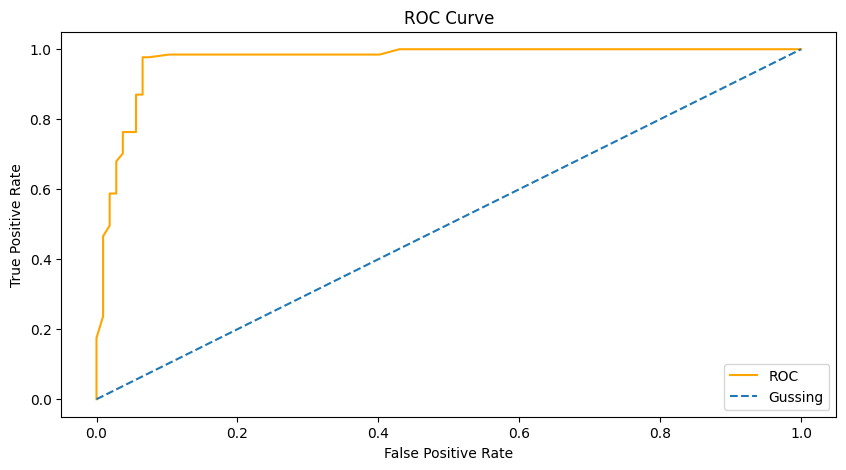

In [67]:
fig, ax = plt.subplots(figsize=(10,5))

def plt_roc(fpr,tpr):
    ax.plot(fpr, tpr, color='orange', label='ROC')
    ax.plot([0,1],[0,1], linestyle='--', label='Gussing')
    ax.legend()
    ax.set(xlabel ='False Positive Rate',
           ylabel='True Positive Rate',
           title='ROC Curve')
plt_roc(fpr,tpr)

In [57]:
roc_auc_score(y_test, y_proba_positive)

0.9698223585646001

In [59]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_preds)

array([[100,   7],
       [  5, 126]])

In [62]:
pd.crosstab(y_test,
            y_preds,
            rownames=['Actual'],
            colnames=['Predicted'])

Predicted,0,1
Actual,,
0,100,7
1,5,126


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       107
           1       0.95      0.96      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238

